# Segmentation attempt
## Run on Dwarp

In [6]:
import pydicom
import numpy as np
import glob
import numpy
import os
#import scipy.ndimage       as nd
#from scipy.ndimage import zoom, generic_gradient_magnitude
from pathlib import Path
# import myVTKPythonLibrary as myvtk
# from pom_funkce_VTK import numpy2VTK
# from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from scipy import ndimage
import copy 
import matplotlib.pyplot as plt
# import skimage
from skimage import measure




base = "/Users/skardova/Documents/MRI_data/2026-Eyes-project/Trial2/"

out_folder = "VTI_shared_view"

img_1 = numpy.load(base + out_folder + os.sep + "view_1_cut.npy")
img_2 = numpy.load(base + out_folder + os.sep + "rot-view_2_cut.npy")

pixel_spacing_1 = numpy.loadtxt(base + out_folder + os.sep + "pixel_spacing_1.txt")
pixel_spacing_2 = numpy.loadtxt(base + out_folder + os.sep + "pixel_spacing_2.txt")

print("pixel spacing 1 = ",  pixel_spacing_1)
print("pixel spacing 2 = ",  pixel_spacing_2)

img_1_shape = img_1.shape
img_2_shape = img_2.shape

print("initial")
print(" img 1 shape = ", img_1_shape)
print(" img 2 shape = ", img_2_shape)


img_2 = ndimage.zoom(img_2, (img_1_shape[0]/img_2_shape[0], img_1_shape[1]/img_2_shape[1], img_1_shape[2]/img_2_shape[2]))

img_1_shape = img_1.shape
img_2_shape = img_2.shape

print("step 1 - same pixel size ")
print(" img 1 shape = ", img_1_shape)
print(" img 2 shape = ", img_2_shape)


img_2 = ndimage.zoom(img_2, (img_1_shape[0]/img_2_shape[0], img_1_shape[1]/img_2_shape[1], img_1_shape[2]/img_2_shape[2]))

img_1_shape = img_1.shape
img_2_shape = img_2.shape

print("step 2 - isotropic resolution")
print(" img 1 shape = ", img_1_shape)
print(" img 2 shape = ", img_2_shape)


img_1 = ndimage.median_filter(img_1, size=3)
img_2 = ndimage.median_filter(img_2, size=3)





pixel spacing 1 =  [0.3125 0.3125 0.5   ]
pixel spacing 2 =  [0.39285713 0.39285713 0.3       ]
initial
 img 1 shape =  (173, 164, 84)
 img 2 shape =  (138, 130, 140)
step 1 - same pixel size 
 img 1 shape =  (173, 164, 84)
 img 2 shape =  (173, 164, 84)
step 2 - isotropic resolution
 img 1 shape =  (173, 164, 84)
 img 2 shape =  (173, 164, 84)


In [7]:
def select_largest(mask):    
    labels_mask = measure.label(mask)                       
    regions = measure.regionprops(labels_mask)
    regions.sort(key=lambda x: x.area, reverse=True)

    print("regions = ", len(regions))

    if len(regions) > 1:
        for rg in regions[1:]:
            labels_mask[rg.coords[:,0], rg.coords[:,1], rg.coords[:,2]] = 0

    return labels_mask




mask = np.zeros(img_1.shape, dtype=np.uint8)


mask[(img_2>2*img_1) & (img_2<3*img_1)]=1

mask[img_1>120]=0



mask = ndimage.median_filter(mask, size=5)
mask[mask>0.5] = 1
mask[mask<=0.5] = 0

mask = select_largest(mask)

# # closing to fill holes
# mask = ndimage.binary_closing(mask, structure=np.ones((3,3,3)))

# opening to remove spikes
mask = ndimage.binary_opening(mask, structure=np.ones((5,5,5)))

labels_mask = select_largest(mask)








# labels_mask = ndimage.median_filter(labels_mask, size=3)
# labels_mask[labels_mask!=0] = 1




numpy.save(base + out_folder + os.sep + 'segmentations/labels_mask', labels_mask)


regions =  100
regions =  1


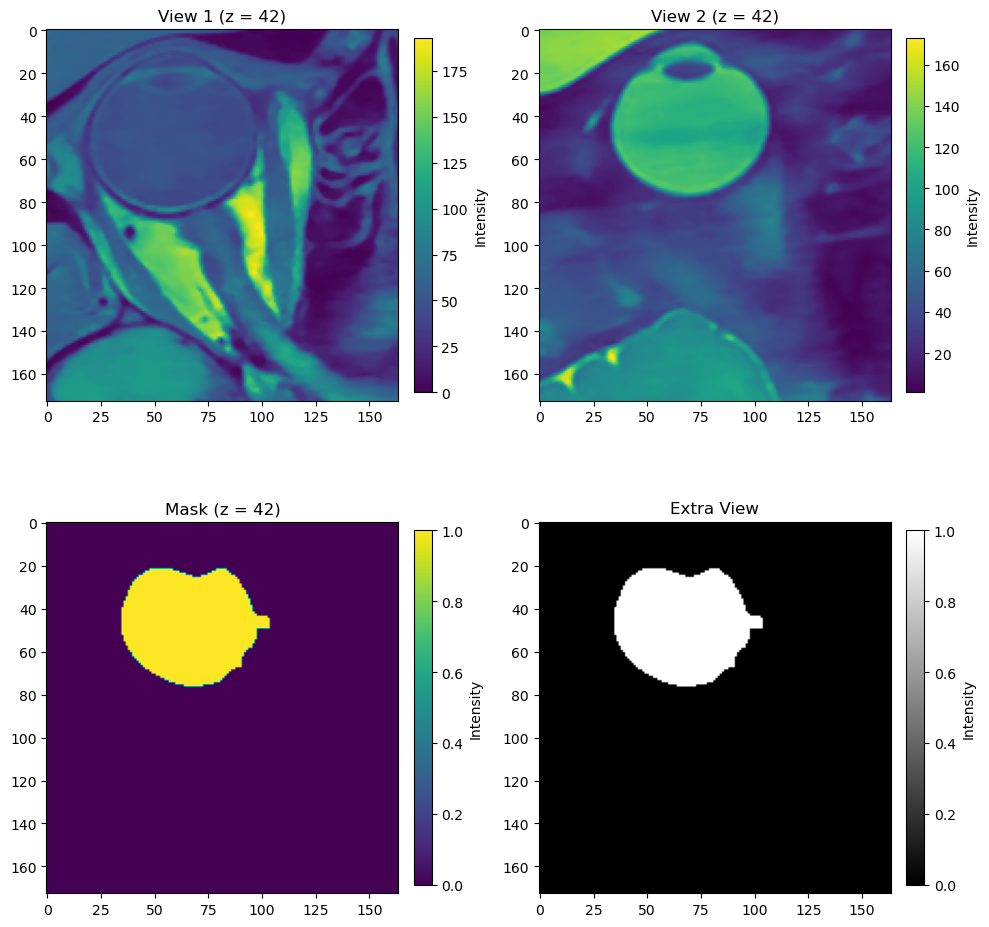

In [8]:
# %matplotlib widget

mid_z_1 = img_1.shape[2] // 2
mid_z_2 = img_2.shape[2] // 2


fig, axs = plt.subplots(2, 2, figsize=(10, 10))

ax1, ax2 = axs[0]
ax3, ax4 = axs[1]

# --- Image 1 ---
im1 = ax1.imshow(img_1[:, :, mid_z_1], cmap="viridis")
ax1.set_title(f"View 1 (z = {mid_z_1})")
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("Intensity")

# --- Image 2 ---
im2 = ax2.imshow(img_2[:, :, mid_z_2], cmap="viridis")
ax2.set_title(f"View 2 (z = {mid_z_2})")
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("Intensity")

# --- Image 3 ---
im3 = ax3.imshow(mask[:, :, mid_z_2], cmap="viridis")
ax3.set_title(f"Mask (z = {mid_z_2})")
cbar3 = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label("Intensity")

# --- Image 4 ---
im4 = ax4.imshow(labels_mask[:, :, mid_z_1], cmap="gray")
ax4.set_title("Extra View")
cbar4 = fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
cbar4.set_label("Intensity")

plt.tight_layout()
plt.show()

In [9]:
from nanomesh import Image
from nanomesh import Volume
from nanomesh import Mesher




vol = Image(labels_mask)

mesher = Mesher(vol)
mesher.generate_contour()

mesher.contour.region_markers

print(mesher.contour.region_markers)

# mesh = mesher.tetrahedralize(opts='-pAq10a500')

# tetra_mesh = mesh.get('tetra')
# tetra_mesh.write(base + out_folder + os.sep + 'segmentations/2-views_segment.vtk')



RegionMarkerList(
    RegionMarker(label=1, point=(53, 78, 7), name='background', constraint=0),
    RegionMarker(label=2, point=(47, 97, 43), name='X', constraint=0)
)


In [10]:
import meshio


mesh = meshio.read(base + out_folder + os.sep + 'segmentations/2-views_segment.vtk')



points = mesh.points
cells = mesh.cells
cell_data = mesh.cell_data


new_cells = []
new_cell_data = {}

# Loop over each cell block (e.g., triangle, tetra, etc.)
for i, cell_block in enumerate(cells):
    cell_type = cell_block.type
    cell_array = cell_block.data
    
    # Get corresponding cell data array
    # (assumes only one data name exists)
    data_name = list(cell_data.keys())[0]
    tags = cell_data[data_name][i]

    # Select only cells with tag == 2
    mask = tags == 2
    filtered_cells = cell_array[mask]
    filtered_tags = tags[mask]

    if len(filtered_cells) > 0:
        new_cells.append((cell_type, filtered_cells))
        
        if data_name not in new_cell_data:
            new_cell_data[data_name] = []
        new_cell_data[data_name].append(filtered_tags)

# Create new mesh
new_mesh = meshio.Mesh(
    points=points,
    cells=new_cells,
    cell_data=new_cell_data
)

# Write mesh
meshio.write(base + out_folder + os.sep + 'segmentations/2-views_segment_filtered.vtk', new_mesh)